Task #2: BBC Sports News Classification

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from zipfile import ZipFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import set_random_seed

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/bbcsports.csv')

Preprocessing

In [6]:
df.head(5)

,Unnamed: 0,text,label
0,0,Sharapova overcomes tough Molik\n\nWimbledon c...,tennis
1,1,GB players warned over security\n\nBritain's D...,tennis
2,2,Federer wins title in Rotterdam\n\nWorld numbe...,tennis
3,3,Mauresmo fights back to win title\n\nWorld num...,tennis
4,4,Agassi into second round in Dubai\n\nFourth se...,tennis


In [8]:
print(df['label'][0])
print('-'*60)
print(df['text'][0])

tennis
------------------------------------------------------------
Sharapova overcomes tough Molik

Wimbledon champion Maria Sharapova recovered from losing the opening set to win the final of the Qatar Open.

The second seed beat fourth-seeded Australian Alicia Molik 4-6 6-1 6-4 for her second title of the year. Molik, who had overcome top seed Amelie Mauresmo in Friday's semi-final, broke Sharapova in the third game of a first set she went on to win. But Sharapova recovered to build up a healthy 5-0 lead in the second set and she never looked back after that. Molik saw her game fall apart as Sharapova broke in the fifth game of the decider to lead 3-2. And although Molik stayed in touch, Sharapova held on to her serve and then finished off the match with an ace after saving a break point in the 10th game.

Sharapova said the key to her victory was her positive approach after losing the first set. "Alicia was dictating terms to me in the first set but in my mind I was always positive

In [11]:
df['label'].value_counts()

,count
label,
football,265
rugby,147
cricket,124
athletics,101
tennis,100


In [12]:
text = df['text'].values
label = df['label'].values

In [13]:
# Convert categorical variable into dummy/indicator variables.
Y = pd.get_dummies(label).values
Y.shape

(737, 5)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    text, Y,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [15]:
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)

In [16]:
# training data preparation
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index

# Convert stories into 0-1 values
X_train = tokenizer.texts_to_matrix(X_train, mode='binary').astype('float32')
X_test = tokenizer.texts_to_matrix(X_test, mode='binary').astype('float32')

In [17]:
X_train.shape, X_test.shape

((589, 10000), (148, 10000))

In [18]:
word_index

{'the': 1,
 'to': 2,
 'a': 3,
 'and': 4,
 'in': 5,
 'of': 6,
 'for': 7,
 'he': 8,
 'is': 9,
 'on': 10,
 'i': 11,
 'but': 12,
 'was': 13,
 'with': 14,
 'his': 15,
 'at': 16,
 'have': 17,
 'that': 18,
 'it': 19,
 'has': 20,
 'be': 21,
 'will': 22,
 'we': 23,
 'said': 24,
 'as': 25,
 'not': 26,
 'from': 27,
 'after': 28,
 'by': 29,
 'had': 30,
 'are': 31,
 'they': 32,
 'an': 33,
 'been': 34,
 'out': 35,
 'first': 36,
 'their': 37,
 'who': 38,
 'game': 39,
 'this': 40,
 'when': 41,
 'up': 42,
 'one': 43,
 'england': 44,
 'against': 45,
 'over': 46,
 'all': 47,
 'two': 48,
 'would': 49,
 'year': 50,
 'win': 51,
 'time': 52,
 'there': 53,
 'last': 54,
 'world': 55,
 'you': 56,
 'if': 57,
 'were': 58,
 'team': 59,
 'back': 60,
 'play': 61,
 'players': 62,
 'also': 63,
 'new': 64,
 'can': 65,
 'before': 66,
 'off': 67,
 'him': 68,
 'my': 69,
 'match': 70,
 'just': 71,
 'three': 72,
 'second': 73,
 '6': 74,
 "it's": 75,
 'which': 76,
 'cup': 77,
 'good': 78,
 'more': 79,
 'so': 80,
 'very': 81,

In [19]:
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.], dtype=float32)

**Model Building : Neural Network**

In [20]:
set_random_seed(42)
model = Sequential()
model.add(Input(shape=(max_words,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,309 (2.45 MB)

 Trainable params: 642,309 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['acc'])

In [28]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - acc: 1.0000 - loss: 1.6891e-05 - val_acc: 1.0000 - val_loss: 2.2978e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 1.0000 - loss: 1.6409e-05 - val_acc: 1.0000 - val_loss: 2.2522e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 1.0000 - loss: 1.5952e-05 - val_acc: 1.0000 - val_loss: 2.2081e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 1.0000 - loss: 1.5521e-05 - val_acc: 1.0000 - val_loss: 2.1637e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 1.0000 - loss: 1.5117e-05 - val_acc: 1.0000 - val_loss: 2.1221e-05
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - acc: 1.0000 - loss: 1.4728e-05 - val_acc: 1.0000 - val_loss: 2.0818e-05
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 1.0000 - loss: 1.4357e-05 - val_acc: 1.0000 - val_loss: 2.0420e-05
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 1.0000 - loss: 1.4006e-05 - val_acc: 1.0000 - val_loss: 2.0063e-05


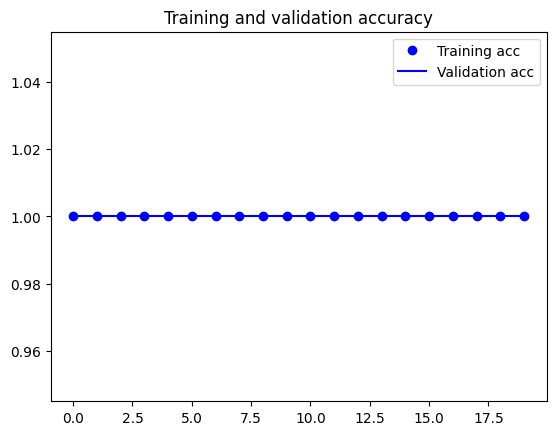

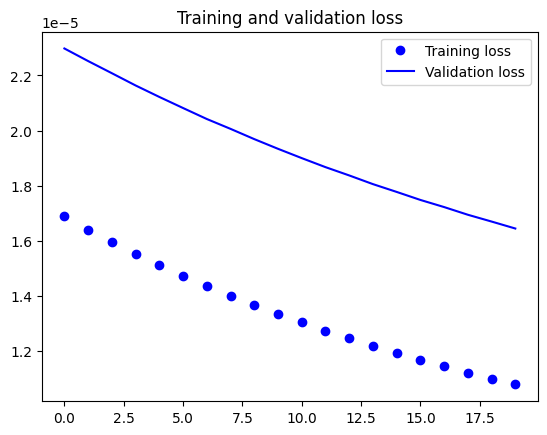

In [31]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [32]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print('Training accuracy:', round(train_acc * 100, 2), '%')
print('Test accuracy:', round(test_acc * 100, 2), '%')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 1.0000 - loss: 1.1233e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9865 - loss: 0.0500
Training accuracy: 100.0 %
Test accuracy: 98.65 %


QUESTIONS

In [33]:
# Predictions
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred,
    labels=np.arange(5),
    target_names=pd.get_dummies(label).columns,
    zero_division=0
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

   athletics       1.00      1.00      1.00        20
     cricket       1.00      0.96      0.98        25
    football       0.96      1.00      0.98        53
       rugby       1.00      0.97      0.98        30
      tennis       1.00      1.00      1.00        20

    accuracy                           0.99       148
   macro avg       0.99      0.99      0.99       148
weighted avg       0.99      0.99      0.99       148



1. Does accuracy vary from class to class label?

In [39]:
names = pd.get_dummies(label).columns

for i in range(5):
    correct = (y_pred[y_true == i] == i).mean()
    print(names[i], ':', round(correct * 100, 2), '%')
print("YES!!")

athletics : 100.0 %
cricket : 96.0 %
football : 100.0 %
rugby : 96.67 %
tennis : 100.0 %
YES!!


2. If so, write the reasons
```
Ans : Unequal class sizes can affect learning. Some sports share
      similar words, while others have more distinct vocabulary.
      Binary input also loses word order and context. These may
      explain differences in class performance.
```